In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from IPython.display import display

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = ':'

# =====================================================================
# CONFIGURACION GENERAL
# =====================================================================
UMBRAL_PR = 1.0
ROLLING_WINDOW = 5
ALPHA = 0.05
MIN_YEARS_TREND = 30

HIST_PERIOD = (1950, 2014)
FUT_PERIOD = (2015, 2100)
DELTA_HIST_PERIOD = (1980, 2014)
DELTA_FUT_PERIOD = (2065, 2100)

LAT_SC = -33.45
LON_SC = -70.66

# =====================================================================
# FUNCIONES AUXILIARES
# =====================================================================
def open_precip(pattern):
    ds = xr.open_mfdataset(pattern, use_cftime=True, chunks={'time': 365})
    ds['pr'] = ds['pr'] * 86400.0
    return ds


def annual_dry_days(ds):
    return (ds['pr'] < UMBRAL_PR).groupby('time.year').sum('time').astype(float)


def rolling_mean_5y(annual_da):
    return annual_da.rolling(year=ROLLING_WINDOW, center=True).mean().dropna('year')


def nearest_gridpoint(ds, lat0, lon0):
    distance = ((ds['lat'] - lat0) ** 2 + (ds['lon'] - lon0) ** 2).compute()
    iy, ix = np.unravel_index(np.argmin(distance.values), distance.shape)
    point = ds.isel(y=iy, x=ix)
    return point, iy, ix


def regression_summary(years, values):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(years) & np.isfinite(values)
    years = years[valid]
    values = values[valid]

    if len(years) < 3 or np.nanstd(values) == 0:
        return np.nan, np.nan, np.nan

    result = stats.linregress(years, values)
    return result.slope * 10.0, result.pvalue, result.rvalue ** 2


def build_sensitivity_table(series, start_years, end_year, scenario_name):
    rows = []
    for start_year in start_years:
        segment = series.sel(year=slice(start_year, end_year))
        if segment.sizes['year'] < MIN_YEARS_TREND:
            continue
        slope_decade, p_value, r2 = regression_summary(segment['year'].values, segment.values)
        rows.append({
            'scenario': scenario_name,
            'start_year': int(start_year),
            'end_year': int(end_year),
            'n_years': int(segment.sizes['year']),
            'trend_days_decade': float(slope_decade),
            'p_value': float(p_value),
            'r2': float(r2),
            'significant': bool(p_value < ALPHA) if np.isfinite(p_value) else False,
            'positive_trend': bool(slope_decade > 0) if np.isfinite(slope_decade) else False,
        })
    return pd.DataFrame(rows)


def summarize_sensitivity(df, label):
    return pd.Series({
        'scenario': label,
        'points': int(len(df)),
        'trend_earliest_start': float(df.iloc[0]['trend_days_decade']),
        'trend_latest_start': float(df.iloc[-1]['trend_days_decade']),
        'min_trend': float(df['trend_days_decade'].min()),
        'max_trend': float(df['trend_days_decade'].max()),
        'median_trend': float(df['trend_days_decade'].median()),
        'positive_fraction': float(df['positive_trend'].mean()),
        'significant_fraction': float(df['significant'].mean()),
    })


def plot_significance_markers(ax, df, color, label):
    sig = df['significant'].values
    ax.plot(df['start_year'], df['trend_days_decade'], color=color, lw=2, label=label)
    ax.scatter(df.loc[sig, 'start_year'], df.loc[sig, 'trend_days_decade'],
               s=36, color=color, edgecolor='black', linewidth=0.5, zorder=3)
    ax.scatter(df.loc[~sig, 'start_year'], df.loc[~sig, 'trend_days_decade'],
               s=36, facecolor='white', edgecolor=color, linewidth=1.2, zorder=3)


def vectorized_linear_trend(annual_da, start_year, end_year):
    da = annual_da.sel(year=slice(start_year, end_year)).compute()
    years = da['year'].values.astype(float)
    values = da.values

    n_time = values.shape[0]
    flat = values.reshape(n_time, -1)
    valid = np.all(np.isfinite(flat), axis=0)

    x = years
    x_mean = x.mean()
    x_anom = x - x_mean
    ssx = np.sum(x_anom ** 2)

    slope = np.full(flat.shape[1], np.nan)
    p_value = np.full(flat.shape[1], np.nan)

    y = flat[:, valid]
    y_mean = y.mean(axis=0)
    y_anom = y - y_mean
    ssy = np.sum(y_anom ** 2, axis=0)
    cov = np.sum(x_anom[:, None] * y_anom, axis=0)

    slope_valid = cov / ssx
    denom = np.sqrt(ssx * ssy)
    r = np.divide(cov, denom, out=np.zeros_like(cov), where=denom > 0)
    r = np.clip(r, -0.999999, 0.999999)

    df = len(x) - 2
    t_stat = np.abs(r) * np.sqrt(df / np.maximum(1e-12, 1.0 - r ** 2))
    p_valid = 2.0 * stats.t.sf(t_stat, df)

    zero_var = ssy <= 0
    slope_valid[zero_var] = np.nan
    p_valid[zero_var] = np.nan

    slope[valid] = slope_valid * 10.0
    p_value[valid] = p_valid

    shape_2d = values.shape[1:]
    slope_da = xr.DataArray(
        slope.reshape(shape_2d),
        coords={dim: da.coords[dim] for dim in da.dims[1:]},
        dims=da.dims[1:],
    ).assign_coords(lon=da['lon'], lat=da['lat'])

    p_da = xr.DataArray(
        p_value.reshape(shape_2d),
        coords={dim: da.coords[dim] for dim in da.dims[1:]},
        dims=da.dims[1:],
    ).assign_coords(lon=da['lon'], lat=da['lat'])

    return slope_da, p_da


def vectorized_welch_delta(hist_da, fut_da):
    hist = hist_da.compute().values.reshape(hist_da.sizes['year'], -1)
    fut = fut_da.compute().values.reshape(fut_da.sizes['year'], -1)
    valid = np.all(np.isfinite(hist), axis=0) & np.all(np.isfinite(fut), axis=0)

    delta_pct = np.full(hist.shape[1], np.nan)
    p_value = np.full(hist.shape[1], np.nan)

    hist_valid = hist[:, valid]
    fut_valid = fut[:, valid]

    mean_hist = hist_valid.mean(axis=0)
    mean_fut = fut_valid.mean(axis=0)
    delta_valid = 100.0 * (mean_fut - mean_hist) / mean_hist
    _, p_valid = stats.ttest_ind(hist_valid, fut_valid, axis=0, equal_var=False, nan_policy='omit')

    delta_pct[valid] = delta_valid
    p_value[valid] = p_valid

    shape_2d = hist_da.values.shape[1:]
    delta_da = xr.DataArray(
        delta_pct.reshape(shape_2d),
        coords={dim: hist_da.coords[dim] for dim in hist_da.dims[1:]},
        dims=hist_da.dims[1:],
    ).assign_coords(lon=hist_da['lon'], lat=hist_da['lat'])

    p_da = xr.DataArray(
        p_value.reshape(shape_2d),
        coords={dim: hist_da.coords[dim] for dim in hist_da.dims[1:]},
        dims=hist_da.dims[1:],
    ).assign_coords(lon=hist_da['lon'], lat=hist_da['lat'])

    return delta_da, p_da


def summarize_map(data_da, p_da, label, kind):
    data = data_da.values
    pvals = p_da.values
    return pd.Series({
        'scenario': label,
        'analysis': kind,
        'mean_value': float(np.nanmean(data)),
        'median_value': float(np.nanmedian(data)),
        'positive_fraction': float(np.nanmean(data > 0)),
        'significant_fraction': float(np.nanmean(pvals < ALPHA)),
        'significant_positive_fraction': float(np.nanmean((data > 0) & (pvals < ALPHA))),
    })


print('1/3: Cargando corrida historica y corridas futuras de Katerina...')
ds_hist = open_precip('./pr1/pr_CHP12_*_historical_*.nc')
ds_ssp370 = open_precip('./pr1/pr_CHP12_*_ssp370_*.nc')
ds_ssp585 = open_precip('./pr1/pr_CHP12_*_ssp585_*.nc')

print('2/3: Calculando dias secos anuales (pr < 1 mm/dia)...')
annual_hist = annual_dry_days(ds_hist).compute()
annual_ssp370 = annual_dry_days(ds_ssp370).compute()
annual_ssp585 = annual_dry_days(ds_ssp585).compute()

rolling_hist = rolling_mean_5y(annual_hist)
rolling_ssp370 = rolling_mean_5y(annual_ssp370)
rolling_ssp585 = rolling_mean_5y(annual_ssp585)

santiago_point, iy_sc, ix_sc = nearest_gridpoint(ds_hist, LAT_SC, LON_SC)
selected_lat = float(santiago_point['lat'].values)
selected_lon = float(santiago_point['lon'].values)

s_hist = annual_hist.isel(y=iy_sc, x=ix_sc)
s_ssp370 = annual_ssp370.isel(y=iy_sc, x=ix_sc)
s_ssp585 = annual_ssp585.isel(y=iy_sc, x=ix_sc)

r_hist = rolling_hist.isel(y=iy_sc, x=ix_sc)
r_ssp370 = rolling_ssp370.isel(y=iy_sc, x=ix_sc)
r_ssp585 = rolling_ssp585.isel(y=iy_sc, x=ix_sc)

print('Punto de Santiago usado por la grilla de Katerina:')
print(f'  lat = {selected_lat:.4f}, lon = {selected_lon:.4f}')
print('  Nota: el rolling de 5 anos se calcula por separado en historico y futuro; no se mezclan periodos.')


1/3: Cargando corrida historica y corridas futuras de Katerina...
2/3: Calculando dias secos anuales (pr < 1 mm/dia)...
Punto de Santiago usado por la grilla de Katerina:
  lat = -33.4003, lon = -70.6832
  Nota: el rolling de 5 anos se calcula por separado en historico y futuro; no se mezclan periodos.


3/3: Analisis 1D en Santiago...


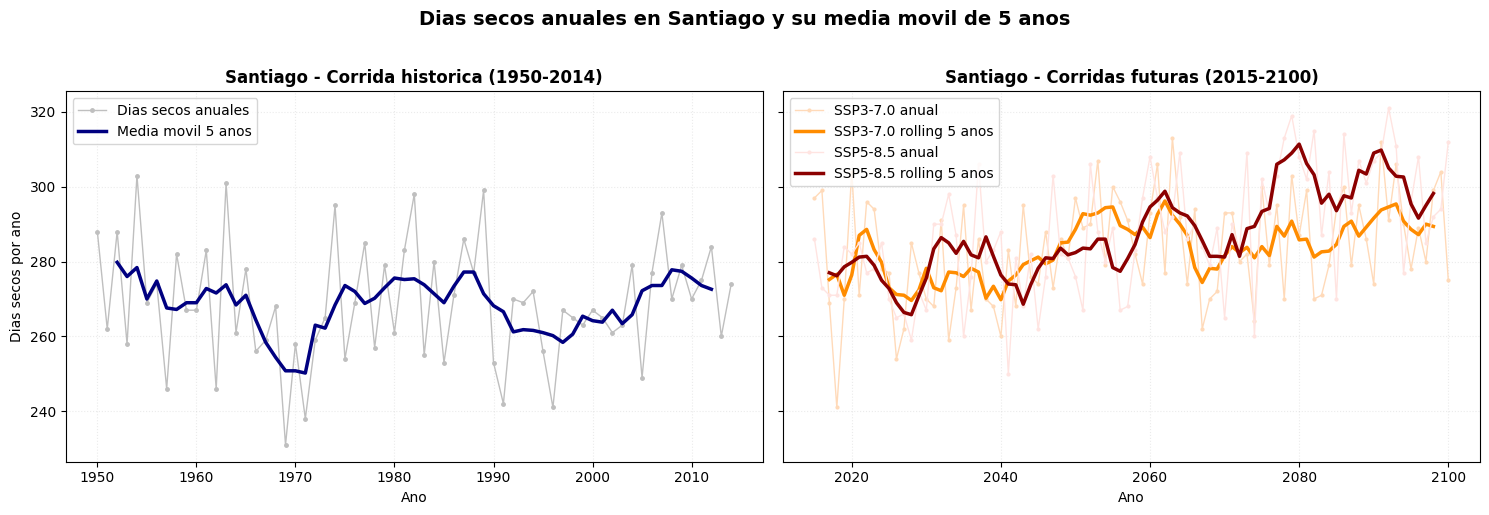

En esta figura:
  - cada punto es el numero de dias secos del ano completo en el punto de grilla de Santiago;
  - cada linea gruesa es la media movil centrada de 5 anos de esos dias secos anuales.


,Escenario,Tendencia (dias/decada),p-value,R^2,Significativo (5%)
0,Historico 1950-2014,-0.130,0.901,0.000,No
1,SSP3-7.0 2015-2100,1.687,0.006,0.088,Si
2,SSP5-8.5 2015-2100,3.656,0.000,0.322,Si


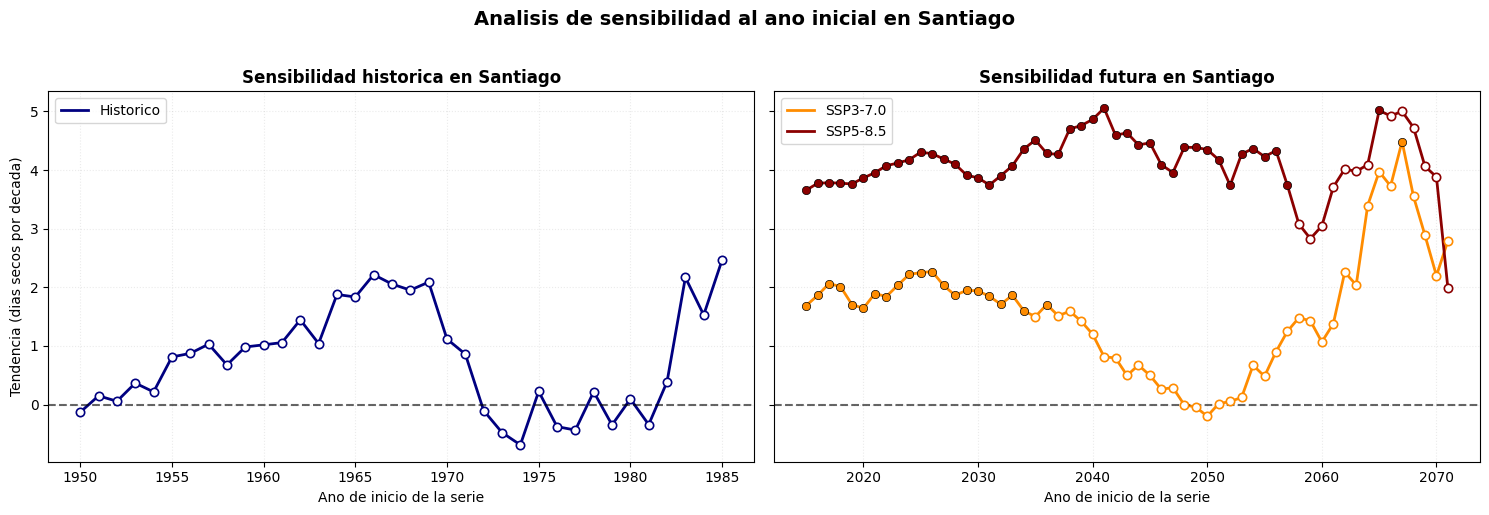

En esta figura de sensibilidad:
  - cada punto es una tendencia lineal, no un rolling mean;
  - para cada ano de inicio, se ajusta una recta usando los dias secos anuales desde ese ano hasta el final del periodo;
  - puntos rellenos indican p < 0.05 y puntos blancos indican que la tendencia no es significativa al 5%.


,Escenario,Numero de puntos,Tendencia inicio mas temprano,Tendencia inicio mas tardio,Minima tendencia,Maxima tendencia,Tendencia mediana,% tendencias positivas,% tendencias significativas
0,Historico,36,-0.130,2.465,-0.688,2.465,0.836,77.778,0.000
1,SSP3-7.0,57,1.687,2.794,-0.200,4.487,1.687,94.737,38.596
2,SSP5-8.5,57,3.656,1.982,1.982,5.056,4.121,100.000,77.193


In [2]:
# =====================================================================
# ANALISIS 1D EN SANTIAGO: SERIE ANUAL, ROLLING 5 ANOS Y SENSIBILIDAD
# =====================================================================
print('3/3: Analisis 1D en Santiago...')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Panel historico
axes[0].plot(s_hist['year'], s_hist.values, color='0.75', lw=1.0, marker='o', markersize=2.5, label='Dias secos anuales')
axes[0].plot(r_hist['year'], r_hist.values, color='navy', lw=2.5, label='Media movil 5 anos')
axes[0].set_title('Santiago - Corrida historica (1950-2014)', fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Dias secos por ano')
axes[0].legend(loc='upper left')

# Panel futuro
axes[1].plot(s_ssp370['year'], s_ssp370.values, color='peachpuff', lw=1.0, marker='o', markersize=2.0, label='SSP3-7.0 anual')
axes[1].plot(r_ssp370['year'], r_ssp370.values, color='darkorange', lw=2.5, label='SSP3-7.0 rolling 5 anos')
axes[1].plot(s_ssp585['year'], s_ssp585.values, color='mistyrose', lw=1.0, marker='o', markersize=2.0, label='SSP5-8.5 anual')
axes[1].plot(r_ssp585['year'], r_ssp585.values, color='darkred', lw=2.5, label='SSP5-8.5 rolling 5 anos')
axes[1].set_title('Santiago - Corridas futuras (2015-2100)', fontweight='bold')
axes[1].set_xlabel('Ano')
axes[1].legend(loc='upper left')

plt.suptitle('Dias secos anuales en Santiago y su media movil de 5 anos', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('En esta figura:')
print('  - cada punto es el numero de dias secos del ano completo en el punto de grilla de Santiago;')
print('  - cada linea gruesa es la media movil centrada de 5 anos de esos dias secos anuales.')

# Tendencias para todo el periodo disponible
trend_rows = []
for label, series in [
    ('Historico 1950-2014', s_hist),
    ('SSP3-7.0 2015-2100', s_ssp370),
    ('SSP5-8.5 2015-2100', s_ssp585),
]:
    slope_decade, p_value, r2 = regression_summary(series['year'].values, series.values)
    trend_rows.append({
        'Escenario': label,
        'Tendencia (dias/decada)': slope_decade,
        'p-value': p_value,
        'R^2': r2,
        'Significativo (5%)': 'Si' if p_value < ALPHA else 'No',
    })
trend_table = pd.DataFrame(trend_rows)
display(trend_table.round(3))

# Sensibilidad al ano inicial
hist_start_years = range(HIST_PERIOD[0], HIST_PERIOD[1] - MIN_YEARS_TREND + 2)
fut_start_years = range(FUT_PERIOD[0], FUT_PERIOD[1] - MIN_YEARS_TREND + 2)

sens_hist = build_sensitivity_table(s_hist, hist_start_years, HIST_PERIOD[1], 'Historico')
sens_ssp370 = build_sensitivity_table(s_ssp370, fut_start_years, FUT_PERIOD[1], 'SSP3-7.0')
sens_ssp585 = build_sensitivity_table(s_ssp585, fut_start_years, FUT_PERIOD[1], 'SSP5-8.5')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

plot_significance_markers(axes[0], sens_hist, 'navy', 'Historico')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.6)
axes[0].set_title('Sensibilidad historica en Santiago', fontweight='bold')
axes[0].set_xlabel('Ano de inicio de la serie')
axes[0].set_ylabel('Tendencia (dias secos por decada)')
axes[0].legend(loc='upper left')

plot_significance_markers(axes[1], sens_ssp370, 'darkorange', 'SSP3-7.0')
plot_significance_markers(axes[1], sens_ssp585, 'darkred', 'SSP5-8.5')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.6)
axes[1].set_title('Sensibilidad futura en Santiago', fontweight='bold')
axes[1].set_xlabel('Ano de inicio de la serie')
axes[1].legend(loc='upper left')

plt.suptitle('Analisis de sensibilidad al ano inicial en Santiago', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('En esta figura de sensibilidad:')
print('  - cada punto es una tendencia lineal, no un rolling mean;')
print('  - para cada ano de inicio, se ajusta una recta usando los dias secos anuales desde ese ano hasta el final del periodo;')
print('  - puntos rellenos indican p < 0.05 y puntos blancos indican que la tendencia no es significativa al 5%.')

sensitivity_summary = pd.DataFrame([
    summarize_sensitivity(sens_hist, 'Historico'),
    summarize_sensitivity(sens_ssp370, 'SSP3-7.0'),
    summarize_sensitivity(sens_ssp585, 'SSP5-8.5'),
])
sensitivity_summary['positive_fraction'] *= 100.0
sensitivity_summary['significant_fraction'] *= 100.0
sensitivity_summary = sensitivity_summary.rename(columns={
    'scenario': 'Escenario',
    'points': 'Numero de puntos',
    'trend_earliest_start': 'Tendencia inicio mas temprano',
    'trend_latest_start': 'Tendencia inicio mas tardio',
    'min_trend': 'Minima tendencia',
    'max_trend': 'Maxima tendencia',
    'median_trend': 'Tendencia mediana',
    'positive_fraction': '% tendencias positivas',
    'significant_fraction': '% tendencias significativas',
})
display(sensitivity_summary.round(3))


Calculando tendencias espaciales y mapas delta...


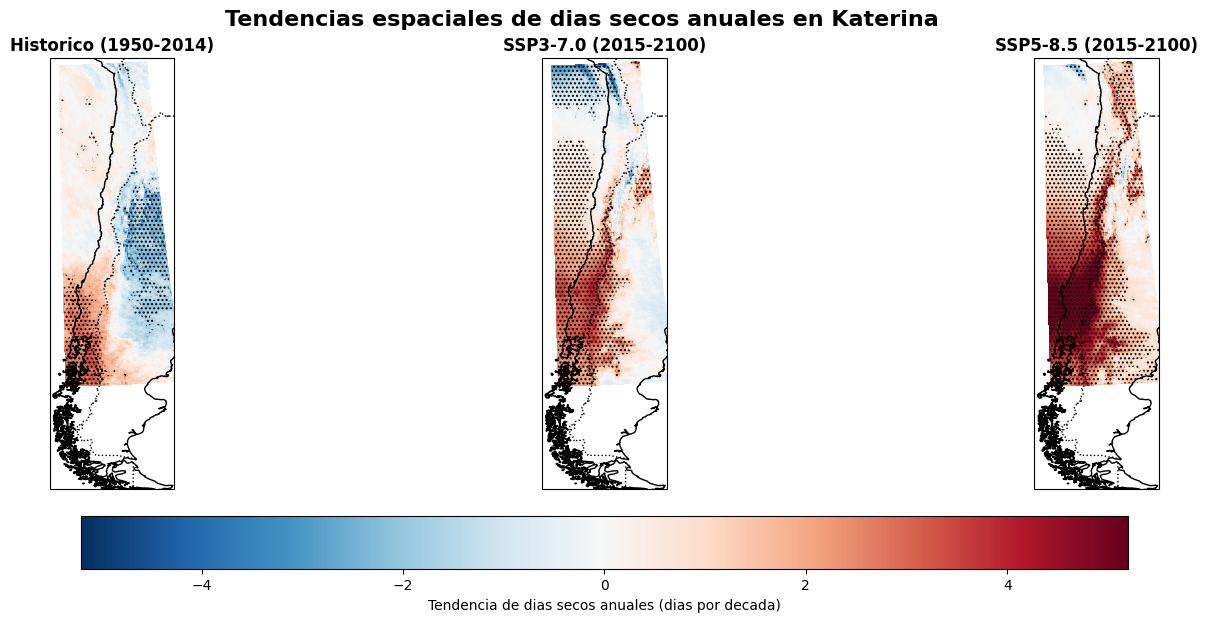

,Escenario,Analisis,Promedio espacial,Mediana espacial,% pixeles con tendencia > 0,% pixeles significativos,% pixeles positivos y significativos
0,Historico (1950-2014),Tendencia,0.017,0.067,53.806,25.058,11.517
1,SSP3-7.0 (2015-2100),Tendencia,0.675,0.376,66.609,49.193,39.798
2,SSP5-8.5 (2015-2100),Tendencia,1.737,1.107,90.952,63.800,62.878


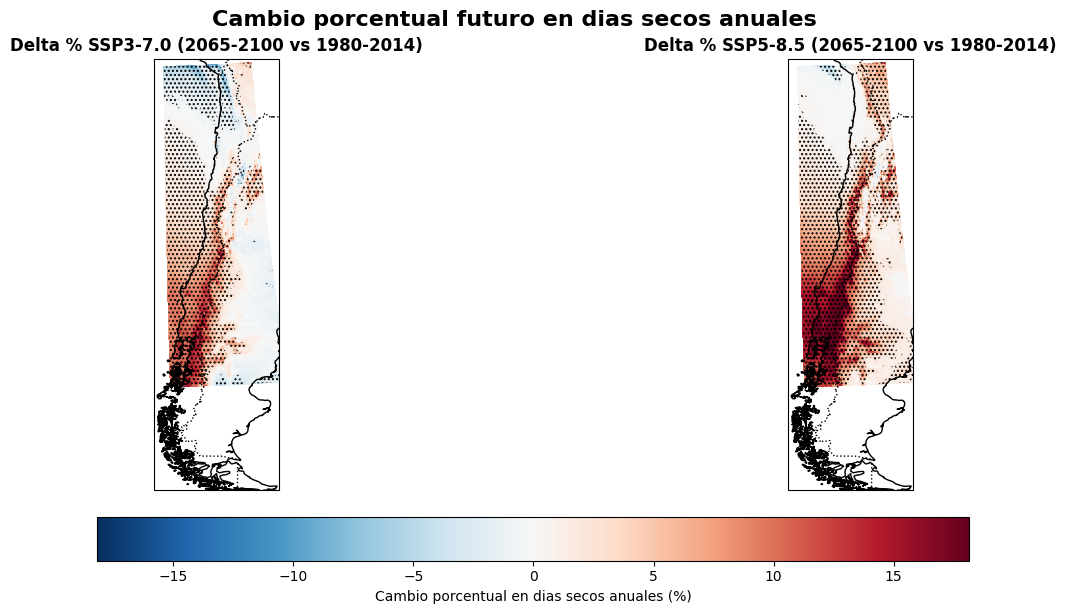

,Escenario,Analisis,Promedio espacial (%),Mediana espacial (%),% pixeles con delta > 0,% pixeles significativos,% pixeles positivos y significativos
0,SSP3-7.0 (2065-2100 vs 1980-2014),Delta porcentual,2.238,0.870,63.114,57.203,44.204
1,SSP5-8.5 (2065-2100 vs 1980-2014),Delta porcentual,5.063,2.747,90.577,68.437,67.197


Metodo de significancia usado:
  - Tendencias 1D y mapas de tendencia: p-value de la pendiente de una regresion lineal simple.
  - Mapas delta: test t de Welch entre 1980-2014 y 2065-2100 para la media anual de dias secos.
  - Umbral de significancia: alpha = 0.05.


In [3]:
# =====================================================================
# MAPAS DE TENDENCIA Y DELTA PORCENTUAL CON SIGNIFICANCIA
# =====================================================================
print('Calculando tendencias espaciales y mapas delta...')

slope_hist, p_hist = vectorized_linear_trend(annual_hist, *HIST_PERIOD)
slope_ssp370, p_ssp370 = vectorized_linear_trend(annual_ssp370, *FUT_PERIOD)
slope_ssp585, p_ssp585 = vectorized_linear_trend(annual_ssp585, *FUT_PERIOD)

trend_maps = [
    ('Historico (1950-2014)', slope_hist, p_hist),
    ('SSP3-7.0 (2015-2100)', slope_ssp370, p_ssp370),
    ('SSP5-8.5 (2015-2100)', slope_ssp585, p_ssp585),
]

trend_limit = np.nanpercentile(
    np.abs(np.concatenate([slope_hist.values.ravel(), slope_ssp370.values.ravel(), slope_ssp585.values.ravel()])),
    98,
)
trend_limit = max(trend_limit, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, (title, slope_da, p_da) in zip(axes, trend_maps):
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([-76, -65, -55, -17])

    im = slope_da.plot.pcolormesh(
        ax=ax,
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=-trend_limit,
        vmax=trend_limit,
        add_colorbar=False,
    )

    sig_mask = xr.where(p_da < ALPHA, 1.0, np.nan)
    ax.contourf(
        slope_da['lon'],
        slope_da['lat'],
        sig_mask,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['....'],
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(title, fontweight='bold', fontsize=12)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.75, pad=0.05)
cbar.set_label('Tendencia de dias secos anuales (dias por decada)')
plt.suptitle('Tendencias espaciales de dias secos anuales en Katerina', fontsize=16, fontweight='bold', y=0.95)
plt.show()

trend_summary = pd.DataFrame([
    summarize_map(slope_hist, p_hist, 'Historico (1950-2014)', 'Tendencia'),
    summarize_map(slope_ssp370, p_ssp370, 'SSP3-7.0 (2015-2100)', 'Tendencia'),
    summarize_map(slope_ssp585, p_ssp585, 'SSP5-8.5 (2015-2100)', 'Tendencia'),
])
trend_summary[['positive_fraction', 'significant_fraction', 'significant_positive_fraction']] *= 100.0
trend_summary = trend_summary.rename(columns={
    'scenario': 'Escenario',
    'analysis': 'Analisis',
    'mean_value': 'Promedio espacial',
    'median_value': 'Mediana espacial',
    'positive_fraction': '% pixeles con tendencia > 0',
    'significant_fraction': '% pixeles significativos',
    'significant_positive_fraction': '% pixeles positivos y significativos',
})
display(trend_summary.round(3))

hist_delta_base = annual_hist.sel(year=slice(*DELTA_HIST_PERIOD))
future_delta_370 = annual_ssp370.sel(year=slice(*DELTA_FUT_PERIOD))
future_delta_585 = annual_ssp585.sel(year=slice(*DELTA_FUT_PERIOD))

delta_ssp370, p_delta_370 = vectorized_welch_delta(hist_delta_base, future_delta_370)
delta_ssp585, p_delta_585 = vectorized_welch_delta(hist_delta_base, future_delta_585)

delta_maps = [
    ('Delta % SSP3-7.0 (2065-2100 vs 1980-2014)', delta_ssp370, p_delta_370),
    ('Delta % SSP5-8.5 (2065-2100 vs 1980-2014)', delta_ssp585, p_delta_585),
]

delta_limit = np.nanpercentile(
    np.abs(np.concatenate([delta_ssp370.values.ravel(), delta_ssp585.values.ravel()])),
    98,
)
delta_limit = max(delta_limit, 5.0)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, (title, delta_da, p_da) in zip(axes, delta_maps):
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([-76, -65, -55, -17])

    im = delta_da.plot.pcolormesh(
        ax=ax,
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=-delta_limit,
        vmax=delta_limit,
        add_colorbar=False,
    )

    sig_mask = xr.where(p_da < ALPHA, 1.0, np.nan)
    ax.contourf(
        delta_da['lon'],
        delta_da['lat'],
        sig_mask,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['....'],
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(title, fontweight='bold', fontsize=12)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.75, pad=0.05)
cbar.set_label('Cambio porcentual en dias secos anuales (%)')
plt.suptitle('Cambio porcentual futuro en dias secos anuales', fontsize=16, fontweight='bold', y=0.95)
plt.show()

delta_summary = pd.DataFrame([
    summarize_map(delta_ssp370, p_delta_370, 'SSP3-7.0 (2065-2100 vs 1980-2014)', 'Delta porcentual'),
    summarize_map(delta_ssp585, p_delta_585, 'SSP5-8.5 (2065-2100 vs 1980-2014)', 'Delta porcentual'),
])
delta_summary[['positive_fraction', 'significant_fraction', 'significant_positive_fraction']] *= 100.0
delta_summary = delta_summary.rename(columns={
    'scenario': 'Escenario',
    'analysis': 'Analisis',
    'mean_value': 'Promedio espacial (%)',
    'median_value': 'Mediana espacial (%)',
    'positive_fraction': '% pixeles con delta > 0',
    'significant_fraction': '% pixeles significativos',
    'significant_positive_fraction': '% pixeles positivos y significativos',
})
display(delta_summary.round(3))

print('Metodo de significancia usado:')
print('  - Tendencias 1D y mapas de tendencia: p-value de la pendiente de una regresion lineal simple.')
print('  - Mapas delta: test t de Welch entre 1980-2014 y 2065-2100 para la media anual de dias secos.')
print('  - Umbral de significancia: alpha = 0.05.')
